In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 107.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


In [ ]:
from huggingface_hub import login

login()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

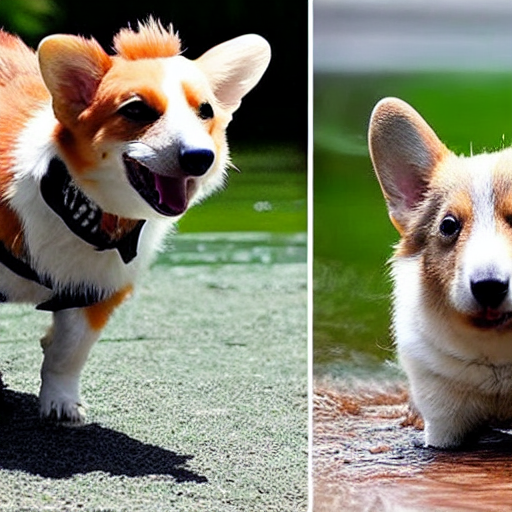

In [15]:
import torch
from diffusers import AutoPipelineForText2Image

model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"  #下载huggingface上面已有的SD v1.5模型

pipe = AutoPipelineForText2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16"
).to("cuda")

prompt = "A corgi and a capibara both play water together"

image = pipe(
    prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

image.save("sixth_sd_image.png")
image

In [16]:
print(pipe)

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

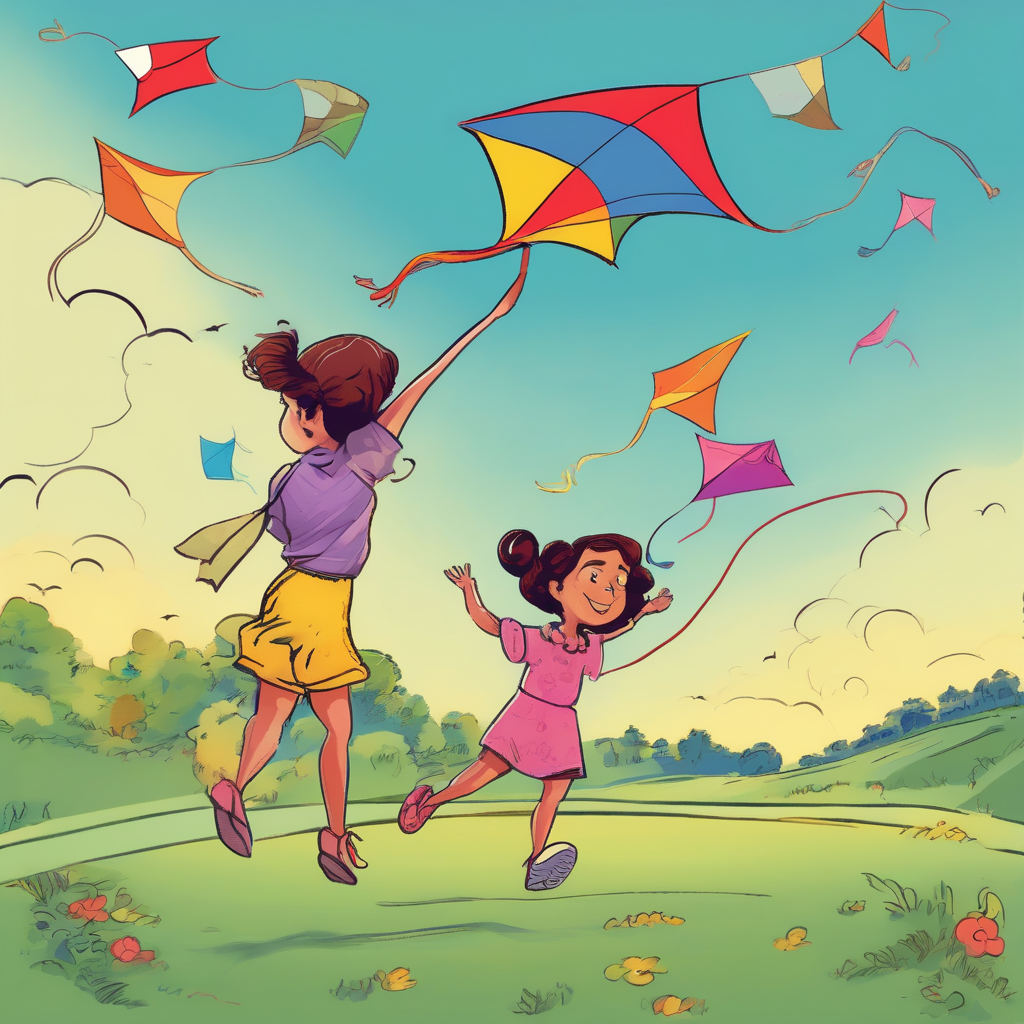

In [13]:
import torch
from diffusers import AutoPipelineForText2Image

model_id = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = AutoPipelineForText2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16"
).to("cuda")

prompt = "A colorful cartoon drawing featuring two girls flying kites"

image = pipe(
    prompt=prompt,
    num_inference_steps=30,
    guidance_scale=7.0
).images[0]

image.save("second_sdxl_image.png")
image

In [14]:
print(pipe)

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "stabilityai/stable-diffusion-xl-base-1.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}



In [17]:
print(pipe.unet.config)

FrozenDict({'sample_size': 64, 'in_channels': 4, 'out_channels': 4, 'center_input_sample': False, 'flip_sin_to_cos': True, 'freq_shift': 0, 'down_block_types': ['CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'DownBlock2D'], 'mid_block_type': 'UNetMidBlock2DCrossAttn', 'up_block_types': ['UpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D'], 'only_cross_attention': False, 'block_out_channels': [320, 640, 1280, 1280], 'layers_per_block': 2, 'downsample_padding': 1, 'mid_block_scale_factor': 1, 'dropout': 0.0, 'act_fn': 'silu', 'norm_num_groups': 32, 'norm_eps': 1e-05, 'cross_attention_dim': 768, 'transformer_layers_per_block': 1, 'reverse_transformer_layers_per_block': None, 'encoder_hid_dim': None, 'encoder_hid_dim_type': None, 'attention_head_dim': 8, 'num_attention_heads': None, 'dual_cross_attention': False, 'use_linear_projection': False, 'class_embed_type': None, 'addition_embed_type': None, 'addition_time_embed_dim': None, 'num_cla

In [19]:
import torch

prompt = "a cute cat wearing sunglasses"

# 1. tokenizer：文字 → token ids
text_inputs = pipe.tokenizer(
    prompt,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt"
)

input_ids = text_inputs.input_ids.to("cuda")

print("input_ids shape:", input_ids.shape)
print("model max length:", pipe.tokenizer.model_max_length)
print("first 20 token ids:", input_ids[0][:20])

# 2. text_encoder：token ids → text embeddings
with torch.no_grad():
    text_embeddings = pipe.text_encoder(input_ids)[0]

print("text_embeddings shape:", text_embeddings.shape)

input_ids shape: torch.Size([1, 77])
model max length: 77
first 20 token ids: tensor([49406,   320,  2242,  2368,  3309, 12906, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407],
       device='cuda:0')
text_embeddings shape: torch.Size([1, 77, 768])
